## 01_EDA.ipynb

## 📊 Analyse Exploratoire des Données (EDA)
## Projet : Analyse de la congestion routière à Casablanca

### Observations

- Aucune valeur manquante
- 22 communes présentes
- Distribution asymétrique
- Présence possible de valeurs extrêmes



Import des librairies

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1️⃣ Analyse de la population

Charger un premier fichier (ex : Population)

In [2]:
df_population = pd.read_csv("../Shets/Table 1. Population size in eac.csv")
df_population.head()


,Commune,ZIP code,Population size,Household,Density
0,Echchallalate,28822,153118.000000,27433.000000,10614.160156
1,Sidi Maarouf,20192,30627.000000,5711.571289,2149.239990
2,Anfa,20040,118056.882812,22528.076172,9013.130859
3,Assoukhour Assawda,20320,120479.875000,24751.125000,35192.347656
4,Ben Msick,20023,134933.812500,22787.908203,18783.462891


Comprendre la structure

In [3]:
df_population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Commune          22 non-null     object 
 1   ZIP code         22 non-null     int64  
 2   Population size  22 non-null     float64
 3   Household        22 non-null     float64
 4   Density          22 non-null     float64
dtypes: float64(3), int64(1), object(1)
memory usage: 1012.0+ bytes


In [4]:
df_population.describe()

,ZIP code,Population size,Household,Density
count,22.000000,22.000000,22.000000,22.000000
mean,21166.772727,124112.486683,23122.318093,15080.476379
std,2622.129377,45389.947084,8911.149877,10484.964939
min,20000.000000,22926.000000,3735.000000,1176.268555
25%,20199.000000,107523.664062,19845.750488,10301.771240
50%,20425.000000,131549.574219,24816.562500,12653.484863
75%,20585.000000,152804.476562,27341.727051,18118.076660
max,29640.000000,184958.093750,37642.000000,41799.218750


In [5]:
df_population.isnull().sum()

Commune            0
ZIP code           0
Population size    0
Household          0
Density            0
dtype: int64

Vérifier doublons

In [6]:
df_population.duplicated().sum()

np.int64(0)

Visualisation simple

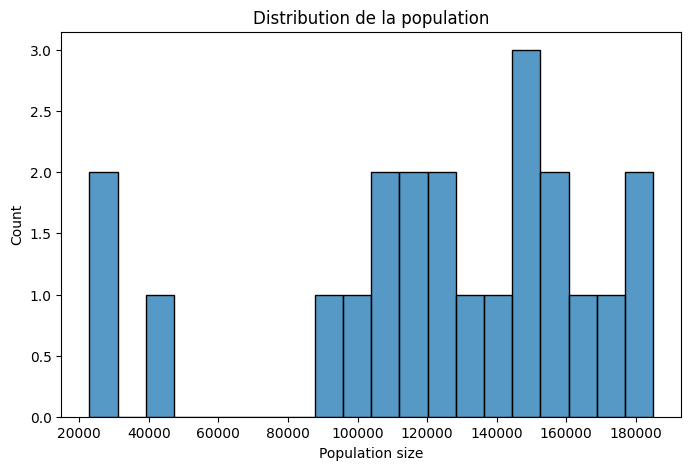

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(df_population["Population size"], bins=20)
plt.title("Distribution de la population")
plt.show()


Vérifie les vrais noms de colonnes

In [8]:
df_population.columns


Index(['Commune', 'ZIP code', 'Population size', 'Household', 'Density'], dtype='object')

## 2️⃣ Analyse des infrastructures routières

Objectifs :

Comprendre la répartition des types de routes

Identifier les zones avec faible infrastructure

Détecter déséquilibre population / routes

 🎯 Objectif

Analyser la répartition des types de routes dans les différentes communes de Casablanca afin de comprendre l’impact potentiel de l’infrastructure routière sur la congestion.

 ❓ Questions d’analyse
 
- Quelle est la distribution des types de routes ?
- Certaines communes ont-elles moins d’infrastructures ?
- Existe-t-il un déséquilibre entre population et routes ?



Chargement des données

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [10]:
df_roads = pd.read_csv("../Shets/Table 3. Type of roads.csv")
df_roads.columns = df_roads.columns.str.strip().str.lower()

df_roads.head()


,commune,zip code,n° of primary roads,n° of secondery roads,n° of highways
0,Echchallalate,28822,6,2,22
1,Sidi Maarouf,20192,12,11,19
2,Anfa,20040,143,154,42
3,Assoukhour Assawda,20320,64,75,2
4,Ben Msick,20023,10,26,18


Inspection des données

In [11]:
df_roads.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   commune                22 non-null     object
 1   zip code               22 non-null     int64 
 2   n° of primary roads    22 non-null     int64 
 3   n° of secondery roads  22 non-null     int64 
 4   n° of highways         22 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 1012.0+ bytes


In [12]:
df_roads.describe()

,zip code,n° of primary roads,n° of secondery roads,n° of highways
count,22.000000,22.000000,22.000000,22.000000
mean,21166.772727,44.090909,52.227273,14.454545
std,2622.129377,45.934642,44.970818,13.696462
min,20000.000000,6.000000,0.000000,0.000000
25%,20199.000000,13.500000,26.000000,4.000000
50%,20425.000000,22.000000,39.500000,10.500000
75%,20585.000000,56.500000,61.750000,21.500000
max,29640.000000,171.000000,154.000000,49.000000


Vérification des valeurs manquantes

In [13]:
df_roads.isnull().sum()


commune                  0
zip code                 0
n° of primary roads      0
n° of secondery roads    0
n° of highways           0
dtype: int64

Visualisation (exemple générique)

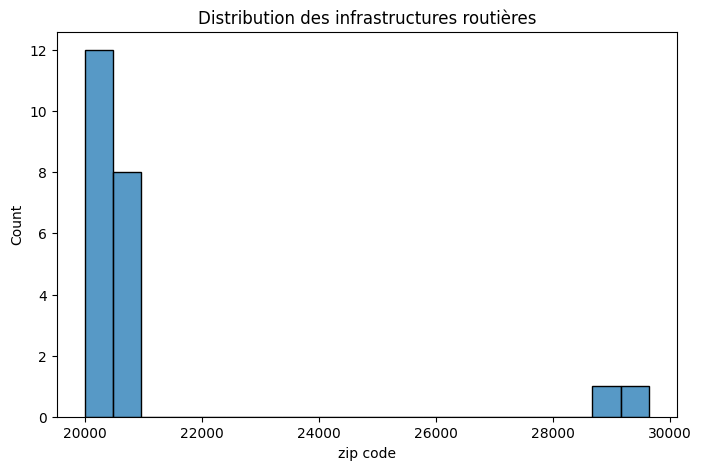

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df_roads.iloc[:,1], bins=20)
plt.title("Distribution des infrastructures routières")
plt.show()


## 3️⃣ Analyse des transports publics 🚊🚌


 🎯 Objectif
Analyser la répartition des transports publics (tramway et bus) par commune afin d’évaluer leur rôle potentiel dans la réduction ou l’aggravation de la congestion routière.

 ❓ Questions d’analyse
- Quelles communes disposent du plus grand nombre de bus ?
- Quelles communes disposent du plus grand nombre de stations tram ?
- Existe-t-il des communes sous-desservies ?
- Y a-t-il un déséquilibre entre population et transport public ?

Chargement des données

In [22]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns


df_transport = pd.read_csv("../Shets/Table 2. Number of Tram and Bus.csv")
df_transport.columns = df_transport.columns.str.strip().str.lower()

df_transport.head()

,commune,zip code,tram-station,bus-station
0,Echchallalate,28822,0,0
1,Sidi Maarouf,20192,0,6
2,Anfa,20040,8,84
3,Assoukhour Assawda,20320,12,42
4,Ben Msick,20023,0,43


Inspection

In [23]:
df_transport.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   commune       22 non-null     object
 1   zip code      22 non-null     int64 
 2   tram-station  22 non-null     int64 
 3   bus-station   22 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 836.0+ bytes


In [24]:
df_transport.describe()


,zip code,tram-station,bus-station
count,22.000000,22.000000,22.000000
mean,21166.772727,6.272727,33.272727
std,2622.129377,8.030785,25.117214
min,20000.000000,0.000000,0.000000
25%,20199.000000,0.000000,14.250000
50%,20425.000000,2.000000,24.000000
75%,20585.000000,11.500000,49.750000
max,29640.000000,24.000000,89.000000


Valeurs manquantes

In [25]:
df_transport.isnull().sum()

commune         0
zip code        0
tram-station    0
bus-station     0
dtype: int64

In [26]:
df_transport.columns

Index(['commune', 'zip code', 'tram-station', 'bus-station'], dtype='object')

📊 Visualisation

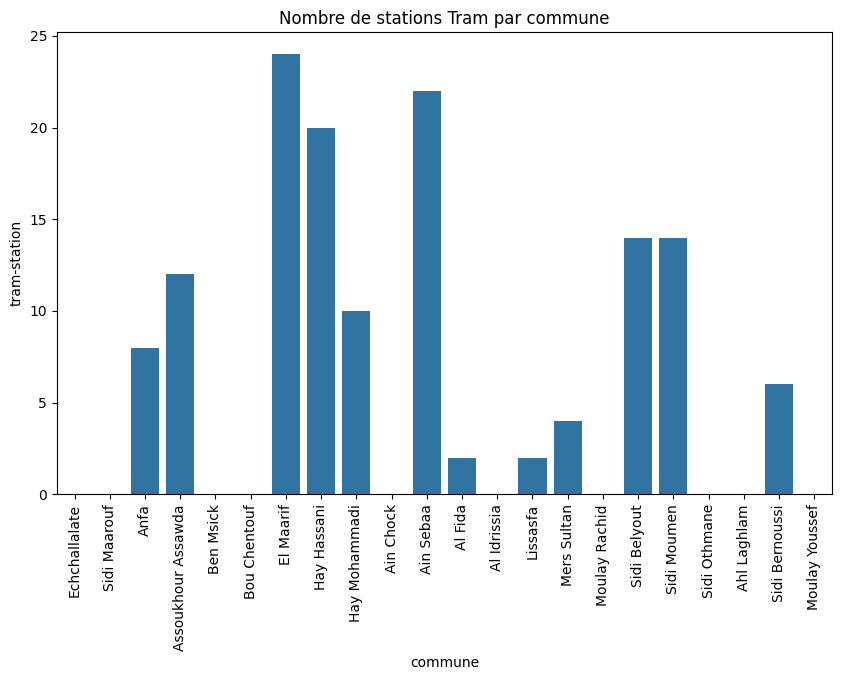

In [27]:
## 🚊 Tram
plt.figure(figsize=(10,6))
sns.barplot(data=df_transport, x="commune", y="tram-station")
plt.xticks(rotation=90)
plt.title("Nombre de stations Tram par commune")
plt.show()

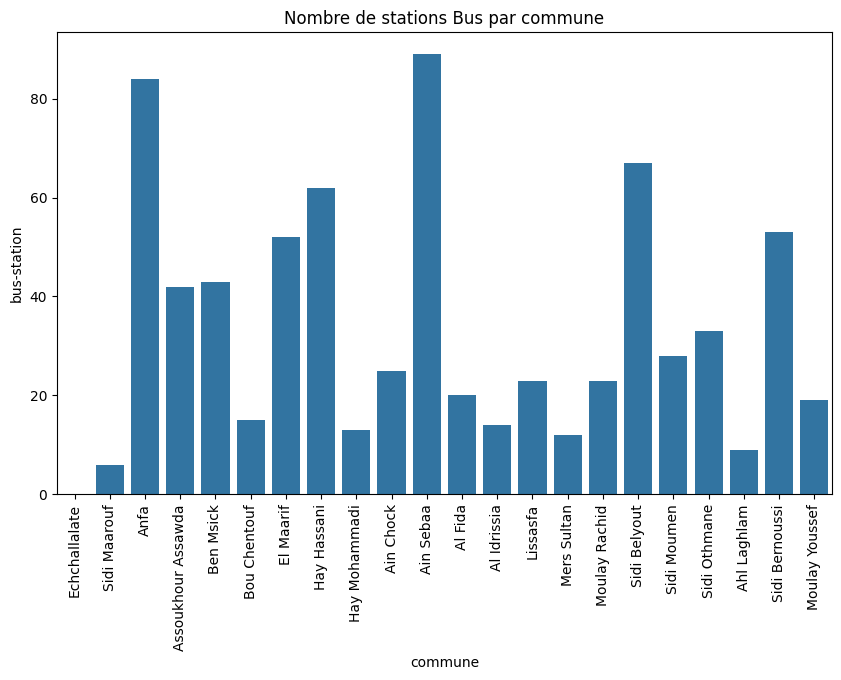

In [28]:
## 🚌 Bus
plt.figure(figsize=(10,6))
sns.barplot(data=df_transport, x="commune", y="bus-station")
plt.xticks(rotation=90)
plt.title("Nombre de stations Bus par commune")
plt.show()

 🔎 Observations

- La répartition des stations de tramway est concentrée dans certaines communes comme :
  - El Maarif
  - Hay Hassani
  - Ain Sebaa
  - Sidi Moumen

- Plusieurs communes ne disposent d’aucune station tram, ce qui peut augmenter la dépendance à la voiture.

- Concernant les stations de bus, la distribution est plus étendue, mais reste inégale.

- Certaines communes fortement peuplées semblent sous-desservies en transport public.

 📌 Interprétation métier

Un déséquilibre entre densité de population et nombre de stations de transport public peut :

- Augmenter l’usage des véhicules privés
- Accroître la congestion routière
- Augmenter le Travel Time Index (TTI)

Une analyse croisée avec la population permettra d’identifier les zones critiques.

## 4️⃣ Analyse de l’occupation du sol (Land Use)


🎯 Objectif

Analyser la répartition des types d’occupation du sol dans les différentes communes afin de comprendre leur impact potentiel sur la congestion routière.

❓ Questions d’analyse
- Quelles communes ont une forte concentration commerciale ?
- Quelles communes sont principalement résidentielles ?
- Les zones commerciales présentent-elles un risque plus élevé de congestion ?

📌 2️⃣ Chargement des données

In [30]:
import pandas as pd 
import numpy as np 

df_land = pd.read_csv("../Shets/Table 4. Land use variables.csv")
df_land.columns = df_land.columns.str.strip().str.lower()

df_land.head()

,commune,zip code,region area (m²),parking area (m²),industrial area (m²),parks area (m²),residential area (m²),university/ institution area (m²),number of commercial buildings
0,Echchallalate,28822,68446680.65,39483.12,1123685.545,1313.570,7.859866e+05,0.000,1
1,Sidi Maarouf,20192,24274975.85,15468.00,233905.170,60665.904,3.099189e+06,53626.466,5
2,Anfa,20040,18134837.18,30090.12,0.000,92624.311,1.471812e+07,57560.521,42
3,Assoukhour Assawda,20320,8653971.31,605.23,1580529.421,123746.788,5.509131e+06,0.000,4
4,Ben Msick,20023,3422170.95,0.00,0.000,17259.213,3.135435e+06,0.000,0


📌 3️⃣ Inspection

In [31]:
df_land.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 9 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   commune                            22 non-null     object 
 1   zip code                           22 non-null     int64  
 2   region area (m²)                   22 non-null     float64
 3   parking area (m²)                  22 non-null     float64
 4   industrial area  (m²)              22 non-null     float64
 5   parks area  (m²)                   22 non-null     float64
 6   residential area (m²)              22 non-null     float64
 7   university/ institution area (m²)  22 non-null     float64
 8   number of commercial buildings     22 non-null     int64  
dtypes: float64(6), int64(2), object(1)
memory usage: 1.7+ KB


In [32]:
df_land.describe()


,zip code,region area (m²),parking area (m²),industrial area (m²),parks area (m²),residential area (m²),university/ institution area (m²),number of commercial buildings
count,22.000000,2.200000e+01,22.000000,2.200000e+01,22.000000,2.200000e+01,22.000000,22.000000
mean,21166.772727,1.225382e+07,19928.476818,7.667943e+05,127713.186682,5.199317e+06,49776.936727,15.136364
std,2622.129377,1.412710e+07,26920.997269,1.557273e+06,146146.294451,3.857186e+06,171088.032360,28.629481
min,20000.000000,1.793995e+06,0.000000,0.000000e+00,0.000000,7.859866e+05,0.000000,0.000000
25%,20199.000000,3.830295e+06,0.000000,1.472795e+04,21450.538500,2.268769e+06,0.000000,1.000000
50%,20425.000000,9.578791e+06,13853.790000,6.409116e+04,69809.046000,3.908904e+06,0.000000,4.000000
75%,20585.000000,1.392198e+07,27330.500000,9.213026e+05,186442.093000,6.742550e+06,30992.532500,7.750000
max,29640.000000,6.844668e+07,108370.880000,5.780587e+06,512919.556000,1.471812e+07,808420.069000,113.000000


In [33]:
df_land.isnull().sum()

commune                              0
zip code                             0
region area (m²)                     0
parking area (m²)                    0
industrial area  (m²)                0
parks area  (m²)                     0
residential area (m²)                0
university/ institution area (m²)    0
number of commercial buildings       0
dtype: int64

📊 4️⃣ Visualisation

In [34]:
df_land.columns

Index(['commune', 'zip code', 'region area (m²)', 'parking area (m²)',
       'industrial area  (m²)', 'parks area  (m²)', 'residential area (m²)',
       'university/ institution area (m²)', 'number of commercial buildings'],
      dtype='object')

Nettoyage des noms de colonnes

In [35]:
df_land.columns = df_land.columns.str.strip().str.lower()

df_land = df_land.rename(columns={
    "region area (m²)": "region_area",
    "parking area (m²)": "parking_area",
    "industrial area  (m²)": "industrial_area",
    "parks area  (m²)": "parks_area",
    "residential area (m²)": "residential_area",
    "university/ institution area (m²)": "university_area",
    "number of commercial buildings": "commercial_buildings"
})

df_land.columns

Index(['commune', 'zip code', 'region_area', 'parking_area', 'industrial_area',
       'parks_area', 'residential_area', 'university_area',
       'commercial_buildings'],
      dtype='object')

In [36]:
## Analyse Intellegente

In [37]:
## Quelle commune est la plus résidentielle ?
df_land.sort_values(by="residential_area", ascending=False)[
    ["commune", "residential_area"]
].head()

,commune,residential_area
2,Anfa,1.471812e+07
10,Ain Sebaa,1.249894e+07
6,El Maarif,1.146206e+07
7,Hay Hassani,9.544390e+06
9,Ain Chock,6.967286e+06


In [38]:
## Quelle commune est la plus industrielle ?
df_land.sort_values(by="industrial_area", ascending=False)[
    ["commune", "industrial_area"]
].head()

,commune,industrial_area
10,Ain Sebaa,5780586.558
20,Sidi Bernoussi,4845999.239
3,Assoukhour Assawda,1580529.421
16,Sidi Belyout,1243868.212
13,Lissasfa,1200871.343


In [39]:
## Quelle commune a le plus de bâtiments commerciaux ?
df_land.sort_values(by="commercial_buildings", ascending=False)[
    ["commune", "commercial_buildings"]
].head()

,commune,commercial_buildings
16,Sidi Belyout,113
6,El Maarif,76
2,Anfa,42
7,Hay Hassani,37
20,Sidi Bernoussi,18


📊 Visualisation

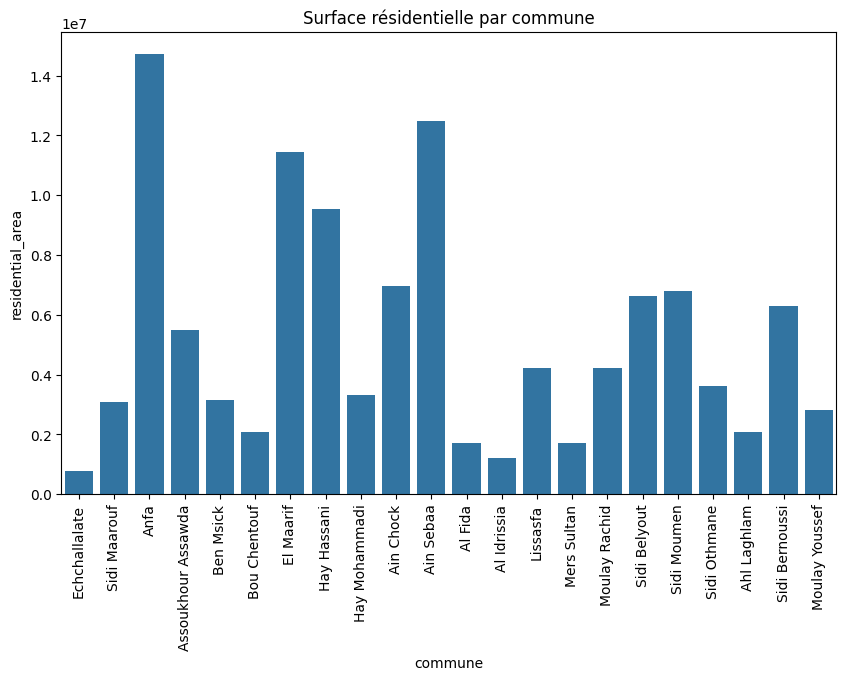

In [40]:
## 🏘 Résidentiel 
plt.figure(figsize=(10,6))
sns.barplot(data=df_land, x="commune", y="residential_area")
plt.xticks(rotation=90)
plt.title("Surface résidentielle par commune")
plt.show()

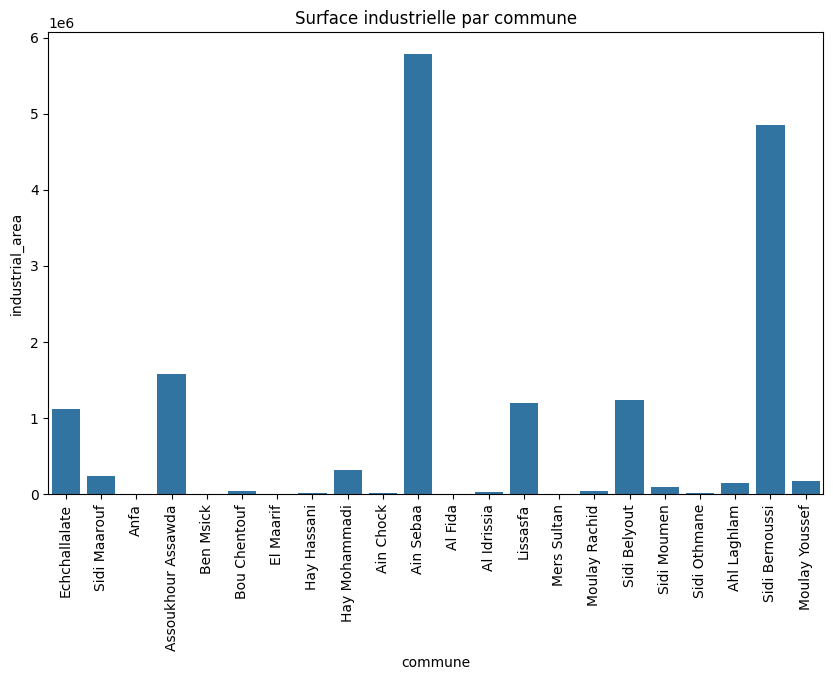

In [41]:
## 🏭 Industriel
plt.figure(figsize=(10,6))
sns.barplot(data=df_land, x="commune", y="industrial_area")
plt.xticks(rotation=90)
plt.title("Surface industrielle par commune")
plt.show()


✅ 1️⃣ Communes les plus résidentielles

🔎 Zones à forte dominante résidentielle

Les communes suivantes présentent les plus grandes surfaces résidentielles :

- Anfa  
- Ain Sebaa  
- El Maarif  
- Hay Hassani  
- Ain Chock  

Ces zones sont susceptibles de générer un trafic sortant important aux heures de pointe (matin) et un trafic entrant en fin de journée.

Cela peut contribuer à une congestion accrue sur les axes principaux reliant ces communes aux zones d'activité.

--------------------------------------------------------------------------------

✅ 2️⃣ Communes les plus industrielles

 🔎 Zones à forte activité industrielle

Les communes les plus industrielles sont :

- Ain Sebaa  
- Sidi Bernoussi  
- Assoukhour Assawda  
- Sidi Belyout  
- Lissasfa  

Les zones industrielles génèrent :

- Un trafic poids lourds
- Des déplacements domicile-travail
- Une forte activité logistique

Ces facteurs peuvent accentuer la congestion, notamment en semaine.

-----------------------------------------------------------------------------------------

✅ 3️⃣ Communes avec le plus de bâtiments commerciaux

🔎 Zones à forte activité commerciale

Les communes avec le plus grand nombre de bâtiments commerciaux sont :

- Sidi Belyout  
- El Maarif  
- Anfa  
- Hay Hassani  
- Sidi Bernoussi  

Les zones commerciales attirent un trafic important durant la journée, particulièrement :

- En milieu de journée
- En fin d’après-midi
- Le week-end

Cela peut entraîner des pics de congestion localisés.

## 5️⃣ Analyse du trafic (Monday → Sunday)

🎯 Objectif
Analyser les variations du trafic sur la semaine afin d’identifier :

- Les heures de pointe
- Les jours les plus congestionnés
- Les différences entre semaine et week-end

Cette analyse permettra de relier la structure urbaine au niveau réel de congestion.

Étape 1 — Charger tous les jours

In [42]:
import pandas as pd

days = {
    "Monday": "Table 5. Monday.csv",
    "Tuesday": "Table 6. Tuesday.csv",
    "Wednesday": "Table 7. Wednesday.csv",
    "Thursday": "Table. 8 Thursday.csv",
    "Friday": "Table. 9 Friday.csv",
    "Saturday": "Table. 10 Saturday.csv",
    "Sunday": "Table. 11 Sunday.csv"
}

traffic_data = {}

for day, file in days.items():
    df = pd.read_csv(f"../Shets/{file}")
    df.columns = df.columns.str.strip().str.lower()
    df["day"] = day
    traffic_data[day] = df

print("Tous les fichiers trafic sont chargés.")

Tous les fichiers trafic sont chargés.


Étape 2 — Fusionner tous les jours

In [43]:
traffic_frames = []

for df in traffic_data.values():
    df = df.reset_index(drop=True)
    df = df.loc[:, ~df.columns.duplicated()]  # supprime colonnes dupliquées
    traffic_frames.append(df)

df_traffic = pd.concat(traffic_frames, ignore_index=True)

df_traffic.shape

(3080, 84)

Identifier les colonnes TTI

In [44]:
tti_columns = [col for col in df_traffic.columns if "tti" in col]
tti_columns[:5]   # vérifier

['tti (min) at 0',
 'tti (min) at  1',
 'tti (min) at  2',
 'tti (min) at  3',
 'tti (min) at  4']

Calculer TTI moyen par ligne

In [45]:
df_traffic["tti_mean"] = df_traffic[tti_columns].mean(axis=1)

TTI moyen par jour

In [46]:
df_traffic.groupby("day")["tti_mean"].mean().sort_values(ascending=False)

day
Wednesday    2.514599
Tuesday      2.497601
Thursday     2.488241
Monday       2.477027
Saturday     2.447124
Friday       2.411974
Sunday       2.271227
Name: tti_mean, dtype: float64

In [47]:
## Étape 1 — Vérifier Monday
df_traffic[df_traffic["day"] == "Monday"][tti_columns].head()

,tti (min) at 0,tti (min) at 1,tti (min) at 2,tti (min) at 3,tti (min) at 4,tti (min) at 5,tti (min) at 6,tti (min) at 7,tti (min) at 8,tti (min) at 9,...,tti (min) at 14,tti (min) at 15,tti (min) at 16,tti (min) at 17,tti (min) at 19,tti (min) at 20,tti (min) at 21,tti (min) at 22,tti (min) at 23,tti (min) at
0,1.264148,1.264148,1.264148,1.024714,1.024714,1.024714,1.024714,1.024714,1.024714,1.014667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.458196,1.458196,1.458196,1.434381,1.395911,1.395911,1.395911,1.395911,1.395911,1.395911,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.326831,1.326831,1.326831,1.226658,1.226658,1.226658,1.226658,1.226658,1.224768,1.236108,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.569610,1.568120,1.571050,1.298888,1.294568,1.296008,1.296008,1.290248,1.274408,1.285928,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.249079,1.249079,1.249079,1.091688,1.091688,1.091688,1.091688,1.091688,1.076619,1.076619,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
df_traffic[df_traffic["day"] == "Monday"][tti_columns].dtypes

tti (min) at 0      float64
tti (min) at  1     float64
tti (min) at  2     float64
tti (min) at  3     float64
tti (min) at  4     float64
tti (min) at  5     float64
tti (min) at  6     float64
tti (min) at  7     float64
tti (min) at  8     float64
tti (min) at  9     float64
tti (min) at  10    float64
tti (min) at  11    float64
tti (min) at  12    float64
tti (min) at  13    float64
tti (min) at  14    float64
tti (min) at  15    float64
tti (min) at  16    float64
tti (min) at  17    float64
tti (min) at 18     float64
tti (min) at  19    float64
tti (min) at  20    float64
tti (min) at  21    float64
tti (min) at  22    float64
tti (min) at  23    float64
tti (min) at 1      float64
tti (min) at 2      float64
tti (min) at 3      float64
tti (min) at 4      float64
tti (min) at 5      float64
tti (min) at 6      float64
tti (min) at 7      float64
tti (min) at 8      float64
tti (min) at 9      float64
tti (min) at 10     float64
tti (min) at 11     float64
tti (min) at 12     

In [49]:
## ✅ Solution
for col in tti_columns:
    df_traffic[col] = pd.to_numeric(df_traffic[col], errors="coerce")

In [50]:
df_traffic["tti_mean"] = df_traffic[tti_columns].mean(axis=1)

df_traffic.groupby("day")["tti_mean"].mean().sort_values(ascending=False)

day
Wednesday    2.514599
Tuesday      2.497601
Thursday     2.488241
Monday       2.477027
Saturday     2.447124
Friday       2.411974
Sunday       2.271227
Name: tti_mean, dtype: float64

cleaning de Monday 

In [51]:
traffic_data["Monday"].columns

Index(['commune', 'zip code', 'index', 'coordinates debut', 'latitude debut',
       'longitude debut', 'index.1', 'coordinates fin', 'latitude fin',
       'longitude fin', 'distance en km', 'trt (min) at 0', 'trt (min) at 1',
       'trt (min) at 2', 'trt (min) at 3', 'trt (min) at 4', 'trt (min) at 5',
       'trt (min) at 6', 'trt (min) at 7', 'trt (min) at 8', 'trt (min) at 9',
       'trt (min) at 10', 'trt (min) at 11', 'trt (min) at 12',
       'trt (min) at 13', 'trt (min) at 14', 'trt (min) at 15',
       'trt (min) at 16', 'trt (min) at 17', 'trt (min) at 18',
       'trt (min) at 19', 'trt (min) at 20', 'trt (min) at 21',
       'trt (min) at 22', 'trt (min) at 23', 'tti (min) at 0',
       'tti (min) at  1', 'tti (min) at  2', 'tti (min) at  3',
       'tti (min) at  4', 'tti (min) at  5', 'tti (min) at  6',
       'tti (min) at  7', 'tti (min) at  8', 'tti (min) at  9',
       'tti (min) at  10', 'tti (min) at  11', 'tti (min) at  12',
       'tti (min) at  13', 'tti (min

In [52]:
traffic_data["Tuesday"].columns

Index(['commune', 'zip code', 'index', 'coordinates debut', 'latitude debut',
       'longitude debut', 'index.1', 'coordinates fin', 'latitude fin',
       'longitude fin', 'distance en km', 'trt (min) at 0', 'trt (min) at 1',
       'trt (min) at 2', 'trt (min) at 3', 'trt (min) at 4', 'trt (min) at 5',
       'trt (min) at 6', 'trt (min) at 7', 'trt (min) at 8', 'trt (min) at 9',
       'trt (min) at 10', 'trt (min) at 11', 'trt (min) at 12',
       'trt (min) at 13', 'trt (min) at 14', 'trt (min) at 15',
       'trt (min) at 16', 'trt (min) at 17', 'trt (min) at 18',
       'trt (min) at 19', 'trt (min) at 20', 'trt (min) at 21',
       'trt (min) at 22', 'trt (min) at 23', 'tti (min) at 0',
       'tti (min) at 1', 'tti (min) at 2', 'tti (min) at 3', 'tti (min) at 4',
       'tti (min) at 5', 'tti (min) at 6', 'tti (min) at 7', 'tti (min) at 8',
       'tti (min) at 9', 'tti (min) at 10', 'tti (min) at 11',
       'tti (min) at 12', 'tti (min) at 13', 'tti (min) at 14',
       'tt

In [53]:
df_traffic[df_traffic["day"] == "Monday"][tti_columns].describe()

,tti (min) at 0,tti (min) at 1,tti (min) at 2,tti (min) at 3,tti (min) at 4,tti (min) at 5,tti (min) at 6,tti (min) at 7,tti (min) at 8,tti (min) at 9,...,tti (min) at 14,tti (min) at 15,tti (min) at 16,tti (min) at 17,tti (min) at 19,tti (min) at 20,tti (min) at 21,tti (min) at 22,tti (min) at 23,tti (min) at
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,2.184501,2.170058,2.190614,2.478803,2.501896,2.477531,2.492631,2.433101,2.574276,2.510230,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.554351,0.553040,0.592731,0.702585,0.709012,0.704825,0.718286,0.683191,0.734239,0.699274,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000945,1.008636,0.997085,0.997085,0.997085,0.997085,1.004755,0.997085,1.012390,1.013788,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,1.810686,1.783155,1.799493,2.051319,2.066027,2.061950,2.058995,2.008277,2.159629,2.056179,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,2.203777,2.184367,2.204504,2.456802,2.494853,2.458499,2.488886,2.452526,2.568330,2.454513,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,2.520643,2.514444,2.554879,2.961362,2.972923,2.968521,2.998487,2.910006,2.994479,2.985468,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,3.881988,3.839016,5.383023,4.804008,4.804008,4.804008,4.789272,4.641910,5.969388,4.884525,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
df_traffic[df_traffic["day"] == "Monday"][tti_columns].isna().sum().sum()

np.int64(10120)

In [55]:
for col in tti_columns:
    df_traffic[col] = (
        df_traffic[col]
        .astype(str)
        .str.replace(",", ".")  # si virgules
        .str.strip()
    )
    
    df_traffic[col] = pd.to_numeric(df_traffic[col], errors="coerce")

In [56]:
df_traffic["tti_mean"] = df_traffic[tti_columns].mean(axis=1)

df_traffic.groupby("day")["tti_mean"].mean().sort_values(ascending=False)

day
Wednesday    2.514599
Tuesday      2.497601
Thursday     2.488241
Monday       2.477027
Saturday     2.447124
Friday       2.411974
Sunday       2.271227
Name: tti_mean, dtype: float64

 🔎 Analyse du Travel Time Index (TTI) moyen par jour

Le classement des jours selon le niveau moyen de congestion est le suivant :

1. Wednesday (2.51)
2. Tuesday (2.49)
3. Thursday (2.48)
4. Monday (2.47)
5. Saturday (2.44)
6. Friday (2.41)
7. Sunday (2.27)

 📌 Interprétation

- Les jours de semaine présentent un niveau de congestion plus élevé que le week-end.
- Le mercredi apparaît comme le jour le plus congestionné.
- Le dimanche est le jour le moins congestionné.
- La baisse relative durant le week-end confirme l’impact des déplacements domicile-travail.

 ## Maintenant on termine l’EDA avec 2 analyses très fortes
 

1️⃣ Heures de pointe globales

<Axes: >

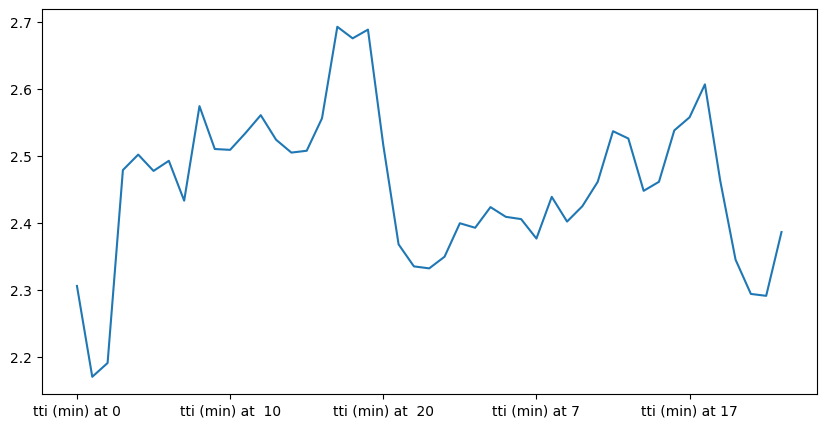

In [57]:
hourly_mean = df_traffic[tti_columns].mean()

hourly_mean.plot(figsize=(10,5))

2️⃣ Commune la plus congestionnée

In [58]:
df_traffic.groupby("commune")["tti_mean"].mean().sort_values(ascending=False).head(10)

commune
Mers Sultan           3.310620
Sidi Belyout          3.293198
Al Fida               2.843337
Hay Hassani           2.764026
Ben Msick             2.752864
Assoukhour Assawda    2.721473
El Maarif             2.716806
Moulay Rachid         2.640016
Al Idrissia           2.622839
Bou Chentouf          2.548735
Name: tti_mean, dtype: float64